## 1. Setup and Imports

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import csv
import random
import statistics
import george
from george import kernels
from scipy.optimize import minimize

## 2. Configuration

In [31]:
# --- Directory and File Paths ---
SPECTRA_DIR = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfaspec_snIa/full_cfa_spectra_extinction_corrected/corrected_spectra'
SNID_OUTPUT_DIR = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfaspec_snIa/full_cfa_spectra_updated'
PARAMS_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/testsuite/cfasnIa_param.dat'
CFA_AGES_FILE = '/Users/pxm588@student.bham.ac.uk/PhD/testsuite/cfa_all_spectra_ages_filtered.txt'
STYLE_SHEET = '/Users/pxm588@student.bham.ac.uk/PhD/testsuite/GausSN.mplstyle'

# --- Output Files ---
SNR_RESULTS_CSV = 'extinction_corrected_snr_results.csv'
RLAP_VALUES_CSV = 'cfa_ext_corrected_SNID_rlap_values.csv'
WEIGHTED_AGE_CSV = 'cfa_SNID_age_results_weighted_bootstrap.csv'
GAUSSIAN_FIT_PLOT = 'cfa_delta_vs_true_age_binned.png'
FINAL_PLOT_FILE = 'cfa_delta_vs_true_age_weighted_bootstrap_plot.png'

# --- Parameters ---
RLAP_THRESHOLD = 5.0
BOOTSTRAP_ITERATIONS = 1000

## 3. Shared Helper Functions

In [32]:
def load_and_prepare_data(cfa_file, snid_file, age_col='Weighted_Mean_Age', unc_col='Bootstrap_Uncertainty'):
    """
    Loads data from CFA true age file and SNID age results file, merges them,
    and returns NumPy arrays for plotting or fitting.
    """
    cfa_data = {}
    try:
        with open(cfa_file, 'r') as f:
            lines = f.readlines()
            for i, line in enumerate(lines, 1):
                if i <= 2: continue
                parts = line.strip().split()
                if not parts: continue
                try:
                    base_name = parts[0].removesuffix('.flm')
                    cfa_data[base_name] = {
                        'true_age': float(parts[2]),
                        'true_unc': float(parts[3])
                    }
                except (ValueError, IndexError):
                    continue
    except FileNotFoundError:
        print(f"Error: The file '{cfa_file}' was not found.")
        return None, None, None, None

    snid_data = {}
    try:
        with open(snid_file, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                base_name = row['Spectrum'].removesuffix('_snid')
                snid_data[base_name] = {
                    'bootstrap_age': float(row[age_col]),
                    'bootstrap_unc': float(row[unc_col])
                }
    except FileNotFoundError:
        print(f"\nError: The file '{snid_file}' was not found.")
        return None, None, None, None
    except (KeyError, ValueError) as e:
        print(f"\nError: Could not parse required columns in '{snid_file}'. Error: {e}")
        return None, None, None, None

    x_vals, y_vals, y_errs, base_names = [], [], [], []
    for base_name, snid_info in snid_data.items():
        if base_name in cfa_data:
            cfa_info = cfa_data[base_name]
            delta = cfa_info['true_age'] - snid_info['bootstrap_age']
            delta_unc = np.sqrt(cfa_info['true_unc'] ** 2 + snid_info['bootstrap_unc'] ** 2)
            x_vals.append(cfa_info['true_age'])
            y_vals.append(delta)
            y_errs.append(delta_unc)
            base_names.append(base_name)

    if not x_vals:
        print("Found 0 matching spectra between the two files.")
        return np.array([]), np.array([]), np.array([]), np.array([])

    sorted_indices = np.argsort(x_vals)
    return (np.array(x_vals)[sorted_indices],
            np.array(y_vals)[sorted_indices],
            np.array(y_errs)[sorted_indices],
            np.array(base_names)[sorted_indices])

## 4. SNR Calculation

In [33]:
def extract_sn_name(spectrum_file):
    basename = os.path.basename(spectrum_file)
    match = re.search(r'(snf\d{8}-\d{3})|(\d{4}[a-zA-Z]{1,2})', basename, re.IGNORECASE)
    if match:
        return match.group(1) or match.group(2)
    return None

def get_redshift(sn_name, params_file):
    try:
        with open(params_file, 'r') as f:
            for line in f:
                if line.strip().startswith('#') or not line.strip():
                    continue
                parts = line.split()
                if len(parts) > 1 and parts[0].lower() == sn_name.lower():
                    return float(parts[1])
    except FileNotFoundError:
        print(f"Error: Parameter file '{params_file}' not found.")
        return None
    except Exception as e:
        print(f"Error reading parameter file: {e}")
        return None
    return None

def analyze_spectrum_for_snr(spectrum_file, params_file):
    SEARCH_WINDOW_REST = (5800, 6400)
    CONTINUUM_WIDTH = 50
    CONTINUUM_PADDING = 50

    try:
        wavelength, flux, uncertainty = np.loadtxt(spectrum_file, unpack=True)
    except Exception as e:
        print(f"  > Error loading spectrum file: {e}")
        return None

    sn_name = extract_sn_name(spectrum_file)
    if not sn_name:
        print(f"  > Could not extract a valid SN name from '{os.path.basename(spectrum_file)}'. Skipping.")
        return None

    redshift = get_redshift(sn_name, params_file)
    if redshift is None:
        print(f"  > Could not find redshift for SN {sn_name}. Skipping.")
        return None

    observed_search_window = tuple(wl * (1 + redshift) for wl in SEARCH_WINDOW_REST)
    search_mask = (wavelength >= observed_search_window[0]) & (wavelength <= observed_search_window[1])
    if not np.any(search_mask):
        print(f"  > Error: No data in broad search window for {sn_name}. Skipping.")
        return None

    min_flux_idx_global = np.where(wavelength == wavelength[search_mask][np.argmin(flux[search_mask])])[0][0]
    found_min_wavelength = wavelength[min_flux_idx_global]
    min_flux = flux[min_flux_idx_global]

    temp_feature_width_obs = 150 * (1 + redshift)
    blue_start = found_min_wavelength - (temp_feature_width_obs / 2) - (CONTINUUM_PADDING * (1 + redshift)) - (CONTINUUM_WIDTH * (1 + redshift))
    blue_end = blue_start + (CONTINUUM_WIDTH * (1 + redshift))
    red_start = found_min_wavelength + (temp_feature_width_obs / 2) + (CONTINUUM_PADDING * (1 + redshift))
    red_end = red_start + (CONTINUUM_WIDTH * (1 + redshift))
    continuum_mask_pass1 = ((wavelength >= blue_start) & (wavelength <= blue_end)) | ((wavelength >= red_start) & (wavelength <= red_end))

    if np.sum(continuum_mask_pass1) < 3:
        print(f"  > Error: Not enough points for first-pass continuum fit for {sn_name}. Skipping.")
        return None

    coeffs_pass1 = np.polyfit(wavelength[continuum_mask_pass1], flux[continuum_mask_pass1], 2)
    continuum_fit_pass1 = np.poly1d(coeffs_pass1)

    blue_edge_idx = min_flux_idx_global
    while blue_edge_idx > 0 and flux[blue_edge_idx] < continuum_fit_pass1(wavelength[blue_edge_idx]):
        blue_edge_idx -= 1
    red_edge_idx = min_flux_idx_global
    while red_edge_idx < len(wavelength) - 1 and flux[red_edge_idx] < continuum_fit_pass1(wavelength[red_edge_idx]):
        red_edge_idx += 1

    observed_feature_region = (wavelength[blue_edge_idx], wavelength[red_edge_idx])
    measured_width = observed_feature_region[1] - observed_feature_region[0]

    continuum_padding_obs = CONTINUUM_PADDING * (1 + redshift)
    continuum_width_obs = CONTINUUM_WIDTH * (1 + redshift)
    blue_continuum_end = observed_feature_region[0] - continuum_padding_obs
    blue_continuum_start = blue_continuum_end - continuum_width_obs
    red_continuum_start = observed_feature_region[1] + continuum_padding_obs
    red_continuum_end = red_continuum_start + continuum_width_obs
    final_continuum_regions = [(blue_continuum_start, blue_continuum_end), (red_continuum_start, red_continuum_end)]
    continuum_mask_pass2 = ((wavelength >= blue_continuum_start) & (wavelength <= blue_continuum_end)) | ((wavelength >= red_continuum_start) & (wavelength <= red_continuum_end))

    if np.sum(continuum_mask_pass2) < 3:
        print(f"  > Error: Not enough points for final continuum fit for {sn_name}. Skipping.")
        return None

    coeffs_final = np.polyfit(wavelength[continuum_mask_pass2], flux[continuum_mask_pass2], 2)
    continuum_fit_final = np.poly1d(coeffs_final)
    continuum_level_at_min = continuum_fit_final(found_min_wavelength)
    feature_depth = continuum_level_at_min - min_flux
    noise = None
    if uncertainty is not None:
        continuum_uncertainties = uncertainty[continuum_mask_pass2]
        if np.any(continuum_uncertainties > 0):
            noise = np.mean(continuum_uncertainties)
        else:
            print(f"  > Note: Uncertainty column for {sn_name} contains only zero or negative values. Falling back to continuum std dev.")

    if noise is None:
        (blue_start, blue_end), (red_start, red_end) = final_continuum_regions
        blue_mask = (wavelength >= blue_start) & (wavelength <= blue_end)
        red_mask = (wavelength >= red_start) & (wavelength <= red_end)
        std_devs = []
        if np.sum(blue_mask) > 1:
            std_devs.append(np.std(flux[blue_mask]))
        if np.sum(red_mask) > 1:
            std_devs.append(np.std(flux[red_mask]))
        if not std_devs:
            print(f"  > Error: Not enough data points in any continuum region to calculate std dev for {sn_name}. Skipping.")
            return None
        noise = np.mean(std_devs)
    snr = feature_depth / noise if noise > 0 else float('inf')

    return {
        "sn_name": sn_name,
        "snr": f"{snr:.2f}",
        "redshift": f"{redshift:.5f}",
        "feature_depth": f"{feature_depth:.4e}",
        "mean_continuum_noise": f"{noise:.4e}",
        "adaptive_feature_width_A": f"{measured_width:.1f}",
        "min_wavelength_A": f"{found_min_wavelength:.1f}",
        "spectrum_file": os.path.basename(spectrum_file),
    }

def process_directory_for_snr(spectra_dir, params_file, output_csv):
    results = []
    print(f"Starting SNR analysis on directory: '{spectra_dir}'")
    print("-" * 50)

    for entry in os.scandir(spectra_dir):
        if entry.is_file() and entry.name.endswith('.flm'):
            print(f"Processing {entry.name}...")
            spectrum_path = entry.path
            result = analyze_spectrum_for_snr(spectrum_path, params_file)
            if result:
                results.append(result)
                print(f"  > Success! S/N = {result['snr']}")

    if not results:
        print("\nNo spectra were successfully processed for SNR.")
        return

    try:
        with open(output_csv, 'w', newline='') as csvfile:
            fieldnames = results[0].keys()
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(results)
        print(f"\n✅ Successfully processed {len(results)} spectra for SNR.")
        print(f"SNR results have been saved to '{output_csv}'")
    except Exception as e:
        print(f"\n❌ Error writing SNR results to CSV file: {e}")

In [34]:
process_directory_for_snr(SPECTRA_DIR, PARAMS_FILE, SNR_RESULTS_CSV)

Starting SNR analysis on directory: '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfaspec_snIa/full_cfa_spectra_extinction_corrected/corrected_spectra'
--------------------------------------------------
Processing sn2006gj-20060920.43-fast_corrected.flm...
  > Success! S/N = 16.49
Processing sn2008bf-20080403.30-fast_corrected.flm...
  > Success! S/N = 34.55
Processing sn2003ch-20030330.16-fast_corrected.flm...
  > Success! S/N = 6.50
Processing sn1998es-19981116.25-fast_corrected.flm...
  > Success! S/N = 9571199868881928.00
Processing sn2005M-20050214.29-fast_corrected.flm...
  > Success! S/N = 19.41
Processing sn1999dq-19990916.45-fast_corrected.flm...
  > Success! S/N = 48.40
Processing sn1998eg-19981117.18-fast_corrected.flm...
  > Success! S/N = 4.41
Processing sn1996X-19960419.30-fast_corrected.flm...
  > Success! S/N = 59.72
Processing sn2006ac-20060324.36-fast_corrected.flm...
  > Success! S/N = 3.54
Processing sn2001eh-20010922.35-fast_corrected.flm...
  > Success! S/N = 16.

## 5. RLAP Value Extraction

In [35]:
def parse_snid_file_for_rlap(filename):
    ages = []
    rlaps = []
    in_rlap_section = False

    try:
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('### rlap-ordered template listings ###'):
                    in_rlap_section = True
                    next(f)  # Skip the header line
                    continue

                if in_rlap_section:
                    if line.startswith('#--- rlap cutoff'):
                        break
                    if line.startswith('#') or not line:
                        continue

                    parts = line.split()
                    if len(parts) > 9 and parts[9] == 'good':
                        try:
                            age = float(parts[7])
                            rlap = float(parts[4])
                            ages.append(age)
                            rlaps.append(rlap)
                        except (IndexError, ValueError) as e:
                            print(f"Could not parse line in {os.path.basename(filename)}: {line}\nError: {e}")
                            continue

    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        return None, None
    except Exception as e:
        print(f"An unexpected error occurred while reading {filename}: {e}")
        return None, None

    return (ages, rlaps) if ages else (None, None)

def get_snid_output_files(directory):
    return [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.output')]

def save_rlap_results(results, output_file):
    with open(output_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Spectrum', 'rlap_values'])
        for spec, rlap_list in results:
            rlap_str = ' '.join(map(str, rlap_list))
            writer.writerow([spec, rlap_str])

def extract_rlap_values(snid_dir, output_csv):
    results = []
    all_files = get_snid_output_files(snid_dir)
    print(f"Found {len(all_files)} SNID output files to process in '{os.path.basename(snid_dir)}'...")

    for output_file in all_files:
        spectrum_name = os.path.basename(output_file).replace('.output', '')
        print(f"--- Processing {spectrum_name} for RLAP values ---")
        _, SN_rlaps = parse_snid_file_for_rlap(output_file)

        if SN_rlaps is None:
            print(f"Could not extract any data from {spectrum_name}. Skipping.")
            continue
        
        print(f"Parsed {len(SN_rlaps)} total template matches.")
        results.append((spectrum_name, SN_rlaps))

    if results:
        save_rlap_results(results, output_file=output_csv)
        print(f"\n✅ Successfully processed {len(results)} files for RLAP. Results saved to '{output_csv}'.")
    else:
        print("\nNo files were successfully processed for RLAP values.")

In [36]:
extract_rlap_values(SNID_OUTPUT_DIR, RLAP_VALUES_CSV)

Found 2591 SNID output files to process in 'full_cfa_spectra_updated'...
--- Processing sn1998dm-19980923.39-fast_snid for RLAP values ---
Parsed 669 total template matches.
--- Processing sn2008Q-20080209.09-fast_snid for RLAP values ---
Parsed 785 total template matches.
--- Processing sn2000cx-20000921.42-fast_snid for RLAP values ---
Parsed 483 total template matches.
--- Processing sn1997do-19971125.38-fast_snid for RLAP values ---
Parsed 625 total template matches.
--- Processing sn2003W-20030209.35-fast_snid for RLAP values ---
Parsed 856 total template matches.
--- Processing sn2000fa-20001230.43-fast_snid for RLAP values ---
Parsed 458 total template matches.
--- Processing sn1998eg-19981111.16-fast_snid for RLAP values ---
Parsed 713 total template matches.
--- Processing sn1999cf-19990605.21-fast_snid for RLAP values ---
Parsed 1026 total template matches.
--- Processing sn1995al-19951222.47-fast_snid for RLAP values ---
Parsed 667 total template matches.
--- Processing sn20

## 6. Weighted Bootstrap Age Calculation

In [37]:
def parse_snid_file_for_age(filename):
    ages = []
    rlaps = []
    in_rlap_section = False

    try:
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('### rlap-ordered template listings ###'):
                    in_rlap_section = True
                    next(f)  # Skip the header line
                    continue

                if in_rlap_section:
                    if line.startswith('#--- rlap cutoff'):
                        break
                    if line.startswith('#') or not line:
                        continue

                    parts = line.split()
                    if len(parts) > 9 and parts[9] == 'good':
                        try:
                            age = float(parts[7])
                            rlap = float(parts[4])
                            ages.append(age)
                            rlaps.append(rlap)
                        except (IndexError, ValueError) as e:
                            print(f"Could not parse line in {os.path.basename(filename)}: {line}\nError: {e}")
                            continue

    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        return None, None
    except Exception as e:
        print(f"An unexpected error occurred while reading {filename}: {e}")
        return None, None

    return (ages, rlaps) if ages else (None, None)

def calculate_weighted_mean(ages, rlaps):
    if not ages or not rlaps or len(ages) != len(rlaps):
        return None
    
    numerator = sum(age * rlap for age, rlap in zip(ages, rlaps))
    denominator = sum(rlaps)
    
    if denominator == 0:
        return None
        
    return numerator / denominator

def calculate_bootstrap_weighted_mean_uncertainty(ages, rlaps, n_iterations=1000):
    if not ages or len(ages) < 2:
        return None

    bootstrap_weighted_means = []
    n_samples = len(ages)
    
    for _ in range(n_iterations):
        bootstrap_indices = random.choices(range(n_samples), k=n_samples)
        bootstrap_ages = [ages[i] for i in bootstrap_indices]
        bootstrap_rlaps = [rlaps[i] for i in bootstrap_indices]
        weighted_mean = calculate_weighted_mean(bootstrap_ages, bootstrap_rlaps)
        
        if weighted_mean is not None:
            bootstrap_weighted_means.append(weighted_mean)

    if len(bootstrap_weighted_means) < 2:
        return None

    std_dev = statistics.stdev(bootstrap_weighted_means)
    return std_dev

def save_age_results(results, output_file):
    with open(output_file, 'w') as f:
        f.write('Spectrum,Weighted_Mean_Age,Bootstrap_Uncertainty\n')
        for spec, wm_age, bs_unc in results:
            f.write(f'{spec},{wm_age if wm_age is not None else -1.00:.2f},{bs_unc if bs_unc is not None else -1.00:.2f}\n')

def calculate_ages(snid_dir, output_csv, rlap_threshold, bootstrap_iterations):
    results = []
    all_files = get_snid_output_files(snid_dir)
    print(f"Found {len(all_files)} files to process for age calculation in '{os.path.basename(snid_dir)}'...")

    for output_file in all_files:
        spectrum_name = os.path.basename(output_file).replace('.output', '')
        print(f"\n--- Processing {spectrum_name} for age calculation ---")

        SN_ages, SN_rlaps = parse_snid_file_for_age(output_file)

        if SN_ages is None:
            print(f"Could not extract any data from {spectrum_name}. Skipping.")
            continue
        print(f"Parsed {len(SN_ages)} total template matches.")

        filtered_data = [(age, rlap) for age, rlap in zip(SN_ages, SN_rlaps) if rlap > rlap_threshold]

        if len(filtered_data) < 2:
            print(f"Not enough matches with rlap > {rlap_threshold} for {spectrum_name}. Skipping.")
            results.append((spectrum_name, None, None))
            continue

        filtered_ages, filtered_rlaps = zip(*filtered_data)
        print(f"Found {len(filtered_ages)} matches with rlap > {rlap_threshold}.")

        weighted_mean_age = calculate_weighted_mean(list(filtered_ages), list(filtered_rlaps))
        bootstrap_uncertainty = calculate_bootstrap_weighted_mean_uncertainty(list(filtered_ages), list(filtered_rlaps), n_iterations=bootstrap_iterations)

        if weighted_mean_age is not None:
            print(f"  Weighted Mean Age: {weighted_mean_age:.2f} ± {bootstrap_uncertainty:.2f}")

        results.append((spectrum_name, weighted_mean_age, bootstrap_uncertainty))

    if results:
        save_age_results(results, output_file=output_csv)
        print(f"\n✅ Successfully processed {len(results)} files for age calculation. Results saved to '{output_csv}'.")
    else:
        print("\nNo files were successfully processed for age calculation.")

In [38]:
calculate_ages(SNID_OUTPUT_DIR, WEIGHTED_AGE_CSV, RLAP_THRESHOLD, BOOTSTRAP_ITERATIONS)

Found 2591 files to process for age calculation in 'full_cfa_spectra_updated'...

--- Processing sn1998dm-19980923.39-fast_snid for age calculation ---
Parsed 669 total template matches.
Found 668 matches with rlap > 5.0.
  Weighted Mean Age: 24.02 ± 0.70

--- Processing sn2008Q-20080209.09-fast_snid for age calculation ---
Parsed 785 total template matches.
Found 782 matches with rlap > 5.0.
  Weighted Mean Age: -1.35 ± 0.16

--- Processing sn2000cx-20000921.42-fast_snid for age calculation ---
Parsed 483 total template matches.
Found 482 matches with rlap > 5.0.
  Weighted Mean Age: 39.13 ± 1.45

--- Processing sn1997do-19971125.38-fast_snid for age calculation ---
Parsed 625 total template matches.
Found 622 matches with rlap > 5.0.
  Weighted Mean Age: 12.25 ± 0.22

--- Processing sn2003W-20030209.35-fast_snid for age calculation ---
Parsed 856 total template matches.
Found 855 matches with rlap > 5.0.
  Weighted Mean Age: -0.42 ± 0.17

--- Processing sn2000fa-20001230.43-fast_snid

## 7. Gaussian Fit and Plotting

In [41]:
def run_gaussian_fit_and_plot(cfa_ages_file, snid_results_file, output_plot_file, style_sheet):
    x, y, yerr, names = load_and_prepare_data(cfa_ages_file, snid_results_file)

    if x is None or x.size == 0:
        print("Data loading error or no matching data for fitting. Exiting.")
        return

    boundaries = [x.min(), x.max()]
    all_x_pred, all_pred, all_pred_std = [], [], []

    for i in range(len(boundaries) - 1):
        lower_bound, upper_bound = boundaries[i], boundaries[i + 1]
        mask_seg = (x >= lower_bound) & (x < upper_bound)
        x_seg, y_seg, yerr_seg = x[mask_seg], y[mask_seg], yerr[mask_seg]

        if len(x_seg) < 2: continue

        initial_ell = x_seg.max() - x_seg.min()
        initial_metric = max(initial_ell ** 2, 1.0)
        kernel = np.var(y_seg) * kernels.ExpSquaredKernel(metric=initial_metric)
        gp = george.GP(kernel)
        gp.compute(x_seg, yerr_seg)

        def neg_ln_like(p, gp=gp, y_seg=y_seg):
            gp.set_parameter_vector(p)
            ll = gp.log_likelihood(y_seg, quiet=True)
            return -ll if np.isfinite(ll) else 1e25

        def grad_neg_ln_like(p, gp=gp, y_seg=y_seg):
            gp.set_parameter_vector(p)
            return -gp.grad_log_likelihood(y_seg, quiet=True)

        result = minimize(neg_ln_like, gp.get_parameter_vector(), jac=grad_neg_ln_like)
        gp.set_parameter_vector(result.x)

        x_pred_seg = np.linspace(lower_bound, upper_bound, 200)
        pred_seg, pred_var_seg = gp.predict(y_seg, x_pred_seg, return_var=True)
        pred_std_seg = np.sqrt(pred_var_seg)

        all_x_pred.append(x_pred_seg)
        all_pred.append(pred_seg)
        all_pred_std.append(pred_std_seg)

    if not all_x_pred:
        print("No segments had enough data to fit the GP. No plot will be generated.")
        return

    x_pred = np.concatenate(all_x_pred)
    pred = np.concatenate(all_pred)
    pred_std = np.concatenate(all_pred_std)

    plt.style.use(style_sheet)
    fig, ax = plt.subplots(figsize=(12, 8))
    three_sigma_mask = np.abs(y) > 3 * yerr
    ax.errorbar(x[~three_sigma_mask], y[~three_sigma_mask], yerr=yerr[~three_sigma_mask], fmt=".k", capsize=0, label='Data (within 3σ)')
    if np.any(three_sigma_mask):
        ax.errorbar(x[three_sigma_mask], y[three_sigma_mask], yerr=yerr[three_sigma_mask], fmt=".", color='red', capsize=0, label='Data (>3σ from zero)')
    # ax.plot(x_pred, pred, color='green', label='GP Mean Prediction')
    # ax.fill_between(x_pred, pred - pred_std, pred + pred_std, color='green', alpha=0.2, label='GP 1-sigma Confidence')
    ax.axhline(0, color='b', linestyle='--', alpha=0.75, zorder=0, label='Perfect Agreement')
    ax.set_xlabel('True Age (days)')
    ax.set_ylabel('Delta (True Age - SNID Age)')
    ax.set_title('Delta vs. True Age for Weighted Bootstrap Method')
    ax.legend(loc='best')
    ax.set_ylim(-30, 35)
    ax.set_xlim(-20, 70)

    plt.savefig(output_plot_file, dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"\nFinal plot saved to {output_plot_file}")

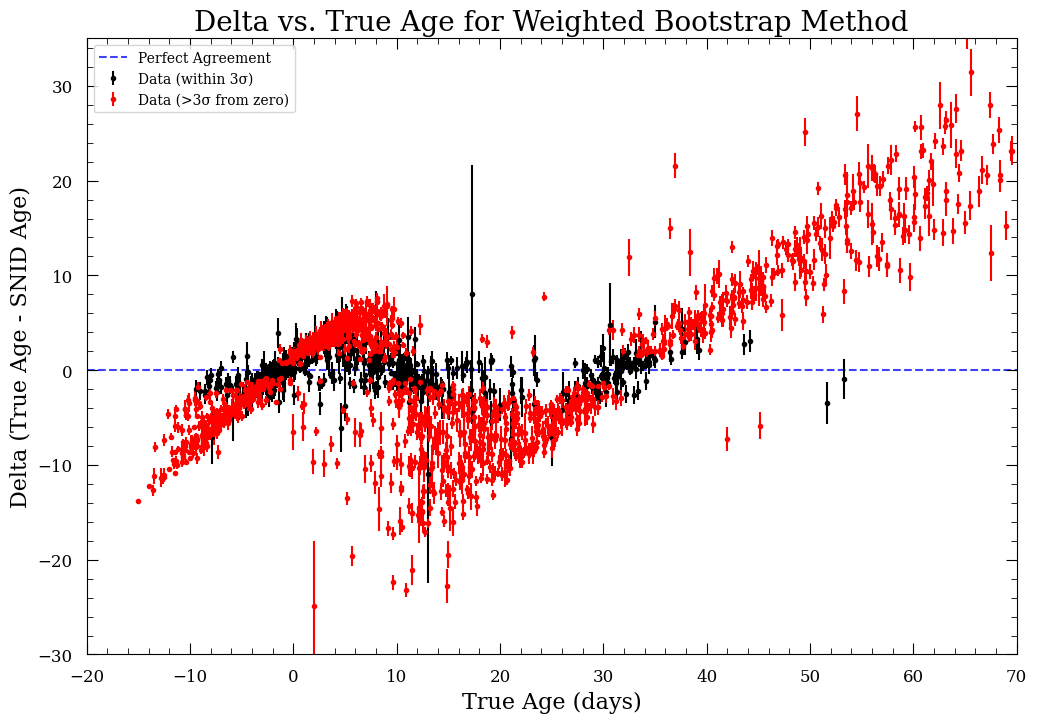


Final plot saved to cfa_delta_vs_true_age_weighted_bootstrap_plot.png


In [42]:
run_gaussian_fit_and_plot(CFA_AGES_FILE, WEIGHTED_AGE_CSV, FINAL_PLOT_FILE, STYLE_SHEET)